**INTRODUCTION**



**OBJECTIVE**



**IMPORT LIBRARIES**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import pickle
import warnings
warnings.filterwarnings("ignore")

**READ METADATA (TXT FILE)**

In [9]:
with open("/content/metadata-rainfall-monthly-maximum-daily-total.txt", "r") as f:
    metadata = f.read()

print(metadata[:500])

# Metadata for Rainfall - Monthly Maximum Daily Total
---
Identifier: 'ac7bfe41-02c5-4161-8d05-8a1125e798ab'
Name: 'rainfall-monthly-maximum-daily-total'
Title: 'Rainfall - Monthly Maximum Daily Total'
Description: 'The highest daily total rainfall for the month recorded at the Changi
  Climate Station.'
Topics:
  - 'Environment'
Keywords:
  - 'Climate'
  - 'NEA'
  - 'Precipitation'
  - 'Rainfall'
  - 'Weather'
Publisher:
  Name: 'National Environment Agency'
  Admin 1:
    Name: 'Ong Chin Hong'


In [10]:
with open("/content/metadata-rainfall-monthly-number-of-rain-days.txt", "r") as f:
    metadata = f.read()

print(metadata[:500])

# Metadata for Rainfall - Monthly Number of Rain Days
---
Identifier: 'f0b330c4-18c5-4d8e-ba95-7c7739297bd2'
Name: 'rainfall-monthly-number-of-rain-days'
Title: 'Rainfall - Monthly Number of Rain Days'
Description: 'The number of rain days (day with rainfall amount of 0.2mm or more)
  in a month recorded at the Changi Climate Station.'
Topics:
  - 'Environment'
Keywords:
  - 'Climate'
  - 'NEA'
  - 'Precipitation'
  - 'Rainfall'
  - 'Weather'
Publisher:
  Name: 'National Environment Agency'
  Ad


In [11]:
with open("/content/metadata-rainfall-monthly-total.txt", "r") as f:
    metadata = f.read()

print(metadata[:500])

# Metadata for Rainfall - Monthly Total
---
Identifier: '5942f8bd-4240-4f68-acd2-a5a276958237'
Name: 'rainfall-monthly-total'
Title: 'Rainfall - Monthly Total'
Description: 'The total monthly rainfall recorded at the Changi Climate Station.'
Topics:
  - 'Environment'
Keywords:
  - 'Climate'
  - 'NEA'
  - 'Precipitation'
  - 'Rainfall'
  - 'Weather'
Publisher:
  Name: 'National Environment Agency'
  Admin 1:
    Name: 'Ong Chin Hong'
    Department: 'CCRS'
    Email: 'ong_chin_hong@nea.gov.sg'
  


**LOAD DATASETS**

In [12]:
# Total rainfall
total = pd.read_csv("/content/sample_data/rainfall-monthly-total.csv")
total['date'] = pd.to_datetime(total['month'])
total = total[['date', 'total_rainfall']].rename(columns={'total_rainfall': 'rainfall'})
total.replace(-999, np.nan, inplace=True)
total.dropna(inplace=True)

# Max daily rainfall
max_daily = pd.read_csv("/content/rainfall-monthly-highest-daily-total.csv")
max_daily['date'] = pd.to_datetime(max_daily['month'])
max_daily = max_daily[['date', 'maximum_rainfall_in_a_day']].rename(
    columns={'maximum_rainfall_in_a_day': 'max_daily'})
max_daily.replace(-999, np.nan, inplace=True)

# Rainy days
rain_days_df = pd.read_csv("/content/rainfall-monthly-number-of-rain-days.csv")
rain_days_df['date'] = pd.to_datetime(rain_days_df['month'])
rain_days_df = rain_days_df[['date', 'no_of_rainy_days']]
rain_days_df.replace(-999, np.nan, inplace=True)

**MERGE DATA**

In [13]:
df = total.merge(max_daily, on='date').merge(rain_days_df, on='date')
df = df.sort_values('date').dropna()

print(df.head())

        date  rainfall  max_daily  no_of_rainy_days
0 1982-01-01     107.1       36.5                10
1 1982-02-01      27.8        9.4                 5
2 1982-03-01     160.8       61.7                11
3 1982-04-01     157.0       45.1                14
4 1982-05-01     102.2       33.0                10


**EDA**

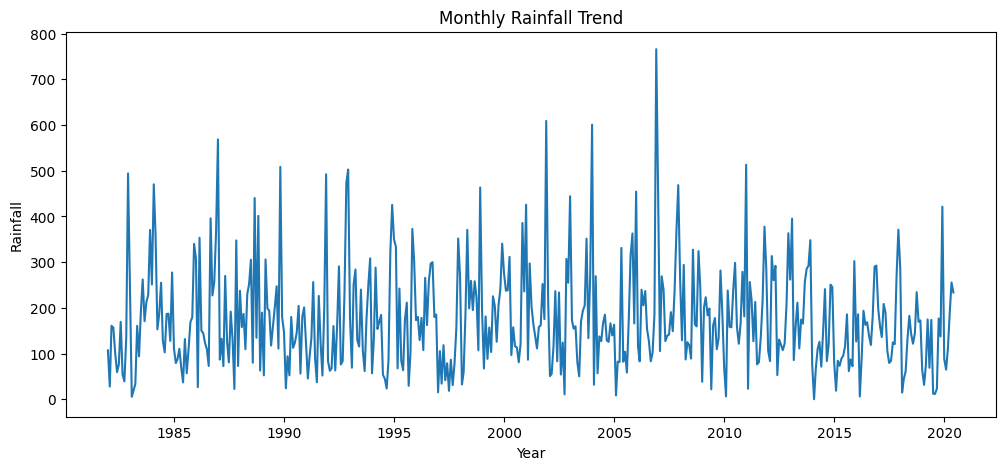

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['rainfall'])
plt.title("Monthly Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.show()

**PROJECT REQUIREMENT (MAX RAINFALL)**

In [15]:

max_rain = df.loc[df['max_daily'].idxmax()]

print("Highest rainfall in a single day:")
print(max_rain)

Highest rainfall in a single day:
date                2011-01-01 00:00:00
rainfall                          513.2
max_daily                         216.2
no_of_rainy_days                     17
Name: 348, dtype: object


**PREPARE DATA FOR PROPHET**

In [16]:
df_prophet = df.rename(columns={'date': 'ds', 'rainfall': 'y'})
df_prophet['rain_days'] = df['no_of_rainy_days']

**CREATE SEASONAL FUTURE REGRESSOR**

In [17]:
monthly_avg_rain_days = df.groupby(df['date'].dt.month)['no_of_rainy_days'].mean()

**TRAIN-TEST SPLIT (TIME SERIES) **

In [18]:
train = df_prophet.iloc[:-12]
test = df_prophet.iloc[-12:]

**BUILD PROPHET MODEL**

In [19]:
model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
model.add_regressor('rain_days')

model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**TEST PREDICTION**

In [20]:
future_test = test[['ds']].copy()
future_test['rain_days'] = test['rain_days']

forecast_test = model.predict(future_test)

**EVALUATION METRICS**

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test['y']
y_pred = forecast_test['yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 54.62602571830058
RMSE: 78.5770723330198


In [22]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
print(performance_metrics(df_cv)[['horizon','mae','rmse']].head())

INFO:prophet:Making 70 forecasts with cutoffs between 1984-05-30 00:00:00 and 2018-06-01 00:00:00


  0%|          | 0/70 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 22.


  horizon        mae       rmse
0 36 days  64.750429  89.348659
1 37 days  63.327091  87.438663
2 38 days  62.056296  85.537826
3 39 days  61.504746  85.120399
4 40 days  62.652704  85.802278


**FINAL FORECAST**

In [23]:

model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
model.add_regressor('rain_days')

model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [24]:
model = Prophet(yearly_seasonality=True)
model.add_regressor('rain_days')
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [25]:
final_model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
final_model.add_regressor('rain_days')

final_model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [26]:
final_model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
final_model.add_regressor('rain_days')

final_model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [27]:
future = final_model.make_future_dataframe(periods=12, freq='MS')
future['rain_days'] = future['ds'].dt.month.map(monthly_avg_rain_days)

forecast = final_model.predict(future)

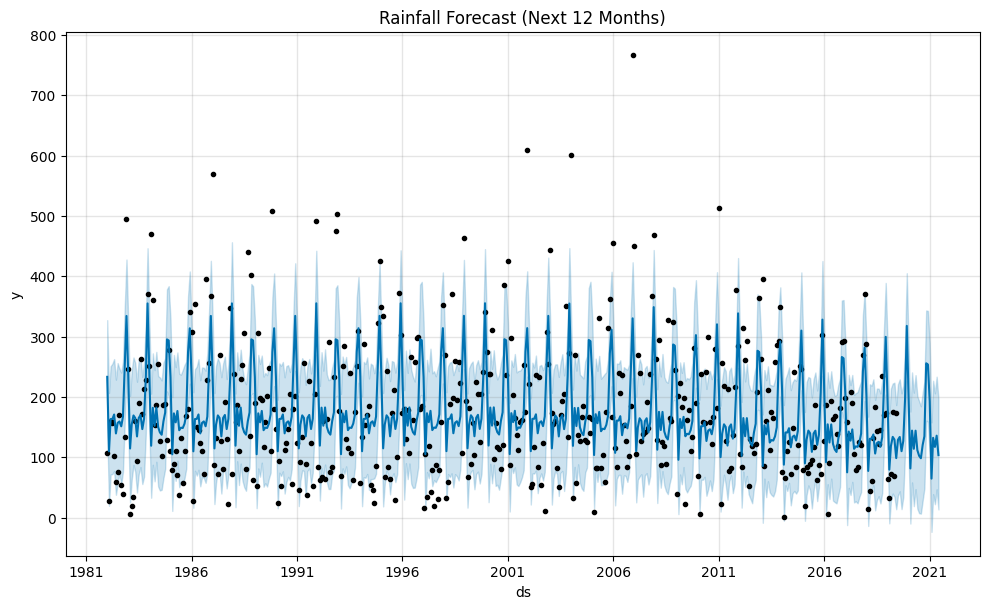

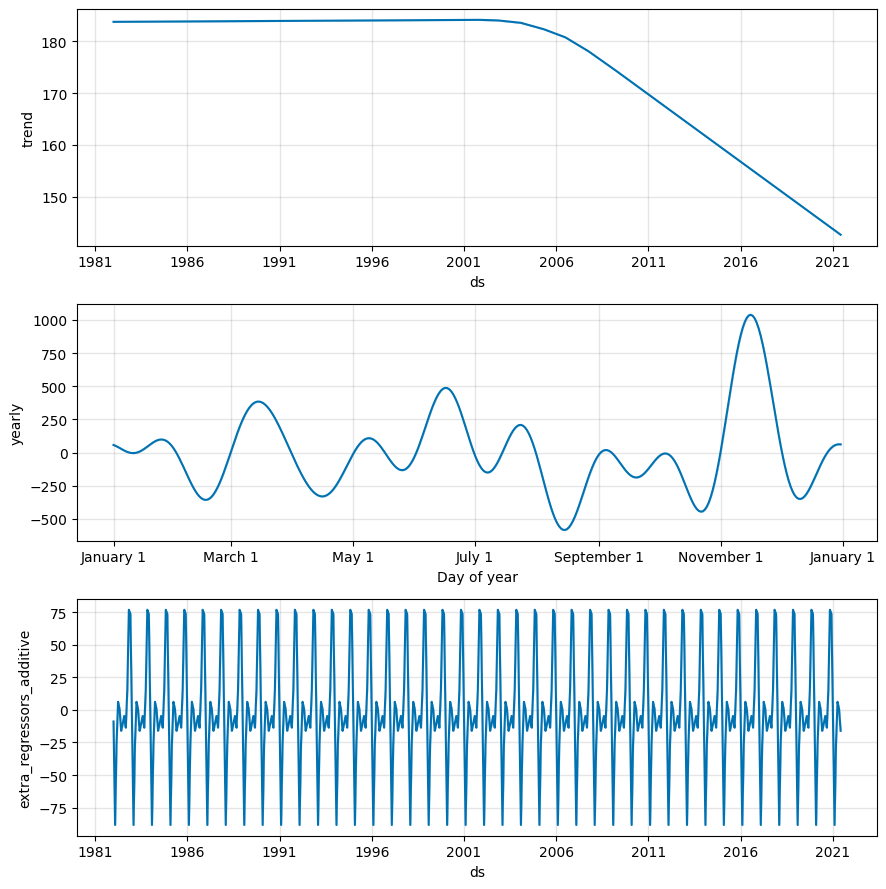

In [28]:
model.plot(forecast)
plt.title("Rainfall Forecast (Next 12 Months)")
plt.show()

model.plot_components(forecast)
plt.show()

In [29]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train['y'], order=(1,1,1)).fit()
arima_pred = arima.forecast(steps=12)

rmse_arima = np.sqrt(mean_squared_error(test['y'], arima_pred))

print("Prophet RMSE:", rmse)
print("ARIMA RMSE:", rmse_arima)

Prophet RMSE: 78.5770723330198
ARIMA RMSE: 120.38499996969287


In [30]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)